# Objectif 

Fichiers preprocessés :

* Données de positions : acouplane_pos.nc
* Données de pression : acouplane_raw_pressure.nc

Date de création : 06/10/2026

In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.io import loadmat
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

In [2]:
if os.name == "nt":  # Windows
    ROOT_PROGRAM = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
else:  # Linux
    ROOT_PROGRAM = "/home/program/ubf_tools"
sys.path.append(ROOT_PROGRAM)

from publication.publication_figure import set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.acouplane_cst import *
from real_data_analysis.acouplane.src.acouplane_utils import *

# Cherche d'un portion d'intérêt par analyse des données de position

## Chargement des données 

In [3]:
ds_pos = xr.open_dataset(ACOUPLANE_POSITIONS_NC_FPATH)

## Positions des tirs sismiques 

### Trajectoire par jours 

La journée la plus propice est la journée du 25/02. 

Pour mémoire l'extrait de donnée étudié avant le transfert du jeu de données complet était le 24/02 autour de 22h00. 


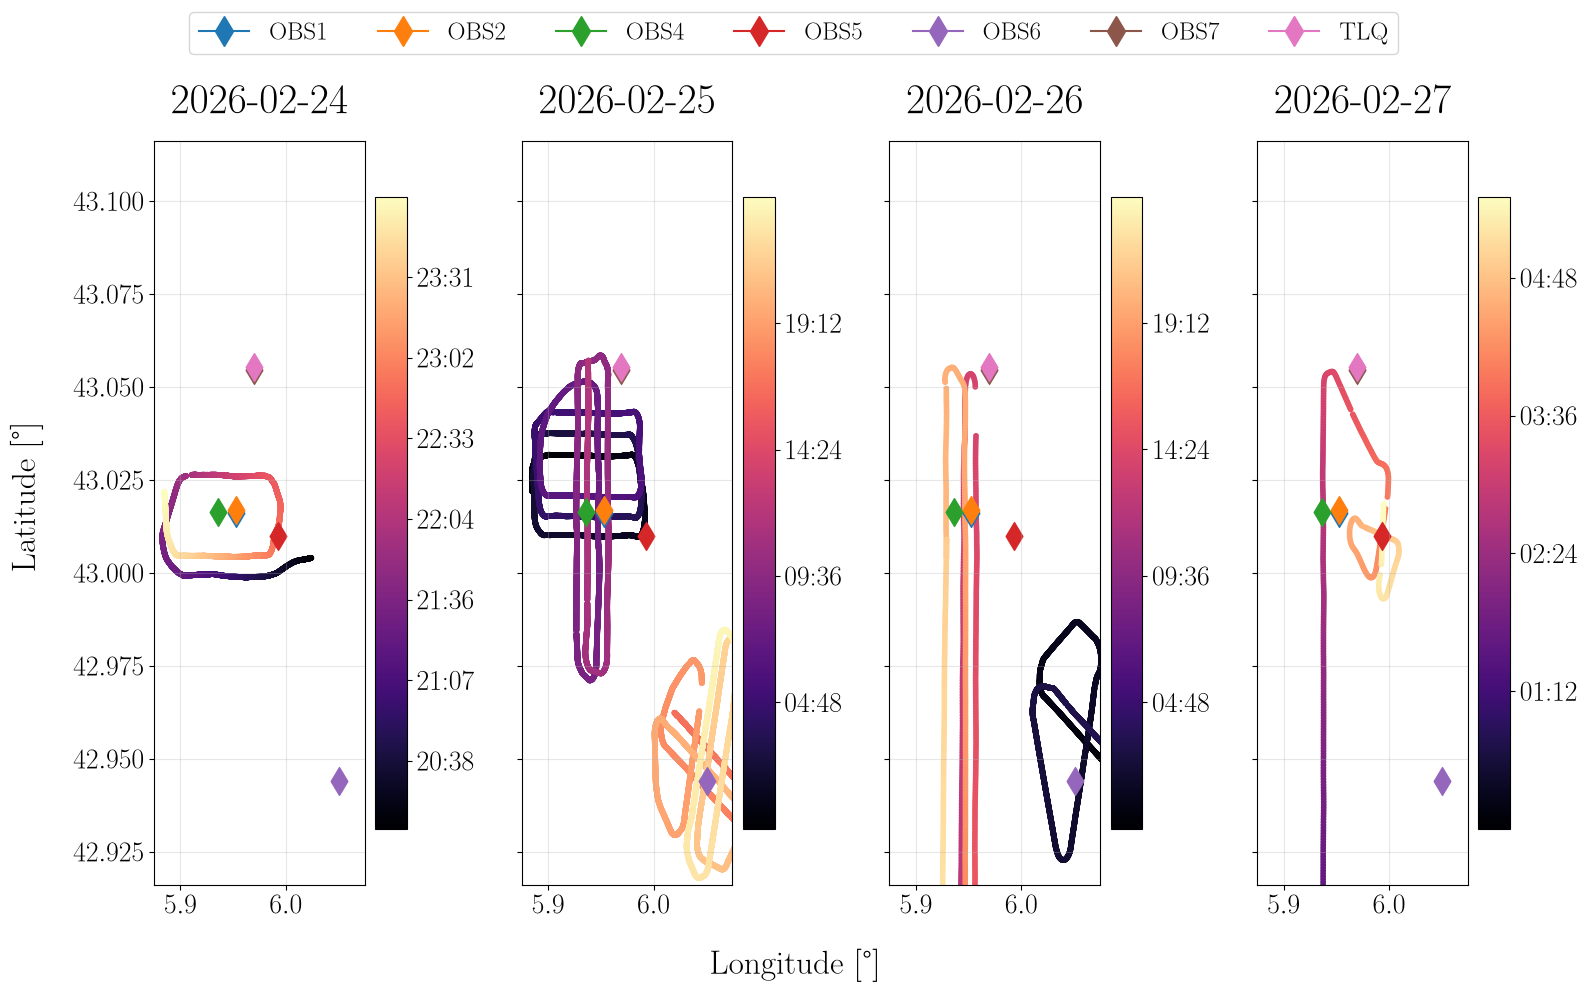

In [4]:
dates = pd.to_datetime(ds_pos.src_datetime.values)
days = dates.normalize().unique()

fig, axes = plt.subplots(
    nrows=1, ncols=len(days), figsize=(16, 10), sharey=True, sharex=True
)

for ax, day in zip(axes, days):

    mask = dates.normalize() == day
    ds_day = ds_pos.isel(src_datetime=mask)

    # Convert time to Matplotlib numerical dates
    date_num = mdates.date2num(pd.to_datetime(ds_day.src_datetime.values))

    sc = ax.scatter(
        ds_day.tir_src_lon,
        ds_day.tir_src_lat,
        c=date_num,
        cmap="magma",
        s=10,
    )

    plot_obs_pos(ds_day, ax=ax, add_legend=False, add_title=False)

    ax.set_title(day.strftime("%Y-%m-%d"))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.3)

    # Time colorbar for this day
    cbar = fig.colorbar(sc, ax=ax)
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    # cbar.set_label("Time")

ax.set_xlim((ds_pos.rcv_lon.mean() - 0.1, ds_pos.rcv_lon.mean() + 0.1))
ax.set_ylim((ds_pos.rcv_lat.mean() - 0.1, ds_pos.rcv_lat.mean() + 0.1))
fig.supxlabel("Longitude [°]")
fig.supylabel("Latitude [°]")

legend_handles = []
for i, id in enumerate(ds_pos.rcv_id.values):
    legend_handles.append(
        Line2D([0], [0], color=f"C{i}", marker="d", label=id, markersize=15)
    )
fig.legend(handles=legend_handles, loc="outside upper center", ncols=len(legend_handles), fontsize=18)

## Journée du 25/02/2026


In [5]:
selected_day = datetime(2026, 2, 25)
ds_pos_day = ds_pos.sel(
    atl_datetime=selected_day.strftime(format="%Y/%m/%d"),
    ais_datetime=selected_day.strftime(format="%Y/%m/%d"),
    src_datetime=selected_day.strftime(format="%Y/%m/%d")
    )

In [6]:
ds_pos_day

<xarray.Dataset> Size: 76MB
Dimensions:         (rcv_id: 7, atl_datetime: 84398, mmsi: 526,
                     ais_datetime: 8640, src_datetime: 22684)
Coordinates:
  * rcv_id          (rcv_id) <U4 112B 'OBS1' 'OBS2' 'OBS4' ... 'OBS7' 'TLQ'
  * atl_datetime    (atl_datetime) datetime64[ns] 675kB 2026-02-25 ... 2026-0...
  * ais_datetime    (ais_datetime) datetime64[ns] 69kB 2026-02-25 ... 2026-02...
  * src_datetime    (src_datetime) datetime64[ns] 181kB 2026-02-25T00:00:00.6...
Dimensions without coordinates: mmsi
Data variables:
    rcv_lon         (rcv_id) float64 56B 5.953 5.953 5.936 5.993 6.051 5.97 5.97
    rcv_lat         (rcv_id) float64 56B 43.02 43.02 43.02 ... 42.94 43.05 43.06
    atl_lon         (atl_datetime) float64 675kB ...
    atl_lat         (atl_datetime) float64 675kB ...
    ais_lon         (mmsi, ais_datetime) float64 36MB ...
    ais_lat         (mmsi, ais_datetime) float64 36MB ...
    tir_SEGD        (src_datetime) int64 181kB ...
    tir_ECOS        (src_datetime) int64 181kB ...
    tir_src_lon     (src_datetime) float64 181kB ...
    tir_src_lat     (src_datetime) float64 181kB ...
    tir_vessel_lon  (src_datetime) float64 181kB ...
    tir_vessel_lat  (src_datetime) float64 181kB ...
Attributes:
    description:              Positions AIS interpolées
    interpolation_time_step:  10s
    campagne:                 ACOUPLANE
    geodesic_frame:           WGS84

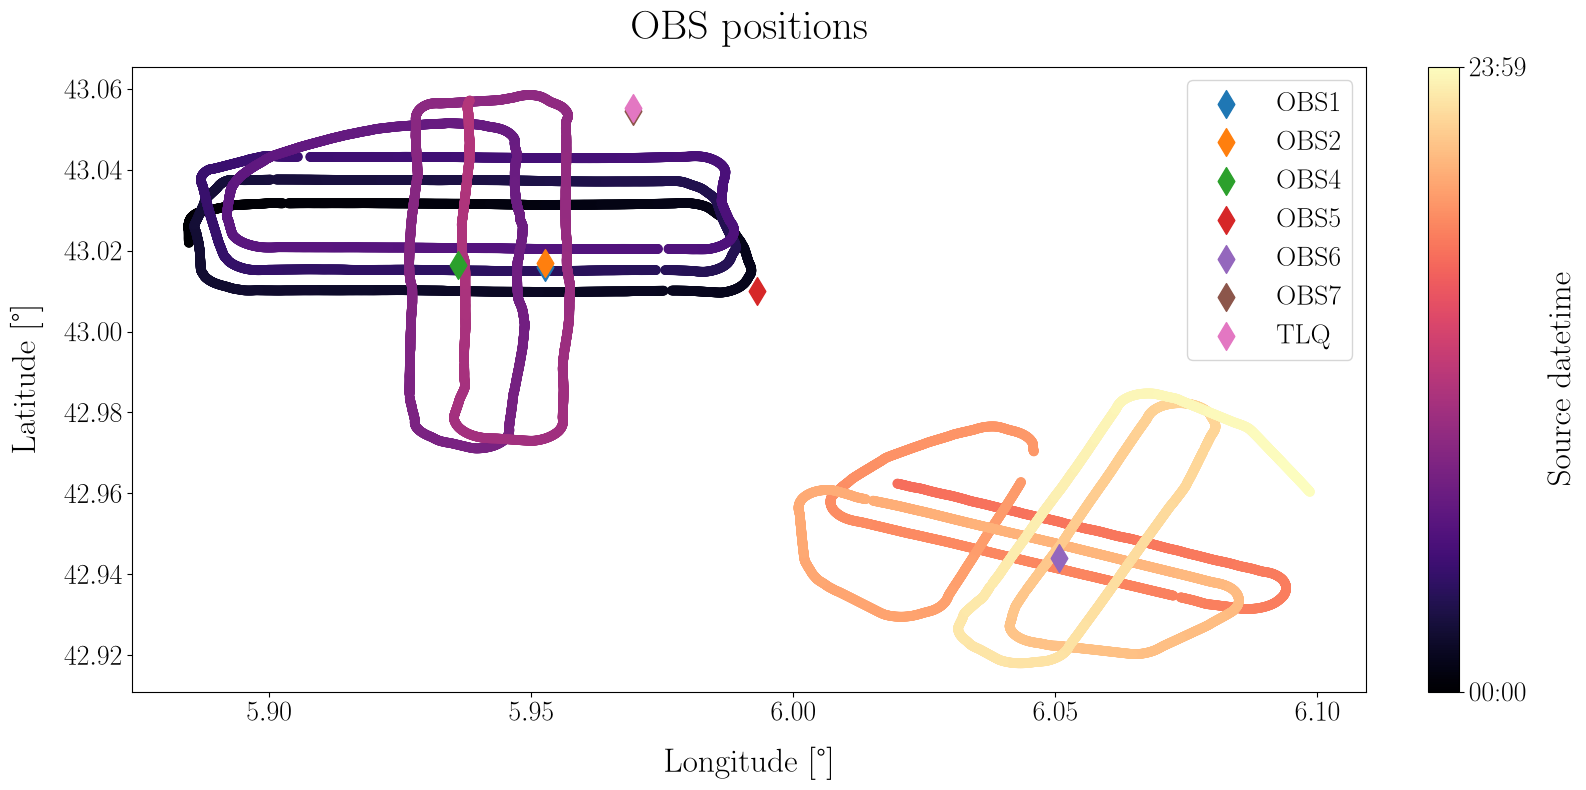

In [7]:
fig, ax = plt.subplots()

dates = ds_pos_day.src_datetime.values
date_num = mdates.date2num(dates)

sc = ax.scatter(
    ds_pos_day.tir_src_lon,
    ds_pos_day.tir_src_lat,
    c=date_num,
    cmap="magma",
)

plot_obs_pos(ds_pos_day, ax=ax)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Source datetime")
cbar.ax.yaxis.set_major_locator(mdates.DayLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

### Matinée 

In [ ]:
morning_start = datetime(2026, 2, 25, 0)
morning_end = datetime(2026, 2, 25, 12)

ds_pos_day_morning = ds_pos_day.sel(
    atl_datetime=slice(morning_start, morning_end),
    ais_datetime=slice(morning_start, morning_end),
    src_datetime=slice(morning_start, morning_end),
    )
ds_pos_day_morning

In [ ]:
fig, ax = plt.subplots()

dates = ds_pos_day_morning.src_datetime.values
date_num = mdates.date2num(dates)

sc = ax.scatter(
    ds_pos_day_morning.tir_src_lon,
    ds_pos_day_morning.tir_src_lat,
    c=date_num,
    cmap="magma",
)

plot_obs_pos(ds_pos_day_morning, ax=ax)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Source datetime")
cbar.ax.yaxis.set_major_locator(mdates.DayLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

### Selection de chaque sections 

#### Section Sud Nord 1

In [ ]:
section_sn1_start = datetime(2026, 2, 25, 9, 50)
section_sn1_end = datetime(2026, 2, 25, 10, 40)
ds_pos_section_sn1 = select_and_plot_section(section_start=section_sn1_start, section_end=section_sn1_end, ds_pos=ds_pos)

#### Section Ouest Est 1

In [ ]:
section_oe1_start = datetime(2026, 2, 25, 0, 20)
section_oe1_end = datetime(2026, 2, 25, 0, 55)
ds_pos_section_oe1 = select_and_plot_section(section_start=section_oe1_start, section_end=section_oe1_end, ds_pos=ds_pos)

#### Section Ouest Est 2

In [ ]:
section_oe2_start = datetime(2026, 2, 25, 2, 40)
section_oe2_end = datetime(2026, 2, 25, 3, 15)
ds_pos_section_oe2 = select_and_plot_section(section_start=section_oe2_start, section_end=section_oe2_end, ds_pos=ds_pos)

#### Section Ouest Est 3

In [ ]:
section_oe3_start = datetime(2026, 2, 25, 4, 55)
section_oe3_end = datetime(2026, 2, 25, 5, 30)
ds_pos_section_oe3 = select_and_plot_section(section_start=section_oe3_start, section_end=section_oe3_end, ds_pos=ds_pos)

### Toutes les sections 

In [ ]:
ds_pos_sections = [ds_pos_section_sn1, ds_pos_section_oe1, ds_pos_section_oe2, ds_pos_section_oe3]
pos_section_label = ["South-North 1", "Ouest-East 1", "Ouest-East 2", "Ouest-East 3"]

In [ ]:
fig, ax = plt.subplots()

for i, ds_pos_section in enumerate(ds_pos_sections):
    sc = ax.scatter(
        ds_pos_section.tir_src_lon,
        ds_pos_section.tir_src_lat,
        color=color(i), 
        label=pos_section_label[i]
    )

plot_obs_pos(ds_pos_section, ax=ax)

# Données de pression

## Chargement des données 

In [ ]:
ds_pressure = xr.open_dataset(ACOUPLANE_PRESSURE_NC_FPATH)

## Convertion des données et calcul vecteurs temps pour slicing 

Les données stockées sont les données raw, il faut donc les convertir et fabriquer le vecteur de temps.

In [ ]:
# Build a vector of datetime for each OBS signal
obs_datetimes = build_obs_datetime_vector(ds_pressure=ds_pressure)

## Données des sections

In [ ]:
ds_pressure

### Section Sud Nord 1

In [ ]:
ds_pressure_section_sn1 = extract_and_plot_pressure_section(section_sn1_start, section_sn1_end, ds_pressure, obs_datetimes, single_fig=False)
# ds_pressure_section_sn1 = extract_pressure_section(section_sn1_start, section_sn1_end, ds_pressure, obs_datetimes)
# ds_pressure_section_sn1 = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure_section_sn1)

### Section Ouest Est 1

In [ ]:
ds_pressure_section_oe1 = extract_and_plot_pressure_section(section_oe1_start, section_oe1_end, ds_pressure, obs_datetimes, single_fig=False)
# ds_pressure_section_oe1 = extract_pressure_section(section_oe1_start, section_oe1_end, ds_pressure, obs_datetimes)
# ds_pressure_section_oe1 = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure_section_oe1)

### Section Ouest Est 2

In [ ]:
ds_pressure_section_oe2 = extract_and_plot_pressure_section(section_oe2_start, section_oe2_end, ds_pressure, obs_datetimes, single_fig=False)
# ds_pressure_section_oe2 = extract_pressure_section(section_oe2_start, section_oe2_end, ds_pressure, obs_datetimes)
# ds_pressure_section_oe2 = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure_section_oe2)

### Section Ouest Est 3

In [ ]:
ds_pressure_section_oe3 = extract_and_plot_pressure_section(section_oe3_start, section_oe3_end, ds_pressure, obs_datetimes, single_fig=False)
# ds_pressure_section_oe3 = extract_pressure_section(section_oe3_start, section_oe3_end, ds_pressure, obs_datetimes)
# ds_pressure_section_oe3 = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure_section_oe3)